# Part 2: ML Model Deployment & Inference

**High-Performance Model Deployment and Inference**

In this notebook, you'll:
- Save trained models in production-ready format
- Load and deploy models for inference
- Perform batch inference on large datasets
- Compare CPU vs GPU inference performance
- Prepare models for Triton Inference Server deployment

**Libraries Used:**
- `joblib` for model serialization (optional)
- `XGBoost` for model inference
- `cuDF` for GPU-accelerated data processing

**Key Concept**: Efficient model deployment is crucial for real-time fraud detection systems!

## 7.1 Environment Setup

In [1]:
%load_ext cudf.pandas

In [2]:
import time
import json
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import joblib

# XGBoost and model handling
import xgboost as xgb
from xgboost import XGBClassifier

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Paths
DATA_DIR = Path("./data")
MODEL_DIR = DATA_DIR / "models"
FEATURE_DIR = DATA_DIR / "features"
DEPLOYMENT_DIR = DATA_DIR / "deployment"
DEPLOYMENT_DIR.mkdir(exist_ok=True)

print(f"\n XGBoost version: {xgb.__version__}")
print(f"\n Directories:")
print(f" Models: {MODEL_DIR}")
print(f" Deployment: {DEPLOYMENT_DIR}")


 XGBoost version: 3.1.2

 Directories:
 Models: data/models
 Deployment: data/deployment


## 7.2 Load Trained Model

First, let's load the XGBoost model we trained in Module 4.

In [9]:
# Check if model exists
model_path = MODEL_DIR / "xgboost_final_model.json"
print(f"Found trained model: {model_path}")

# Load model
model = xgb.Booster()
model.load_model(str(model_path))

print(f"\n Model Information:")
print(f" Number of trees: {model.num_boosted_rounds()}")
print(f" Feature count: {model.num_features()}")

Found trained model: data/models/xgboost_final_model.json

 Model Information:
 Number of trees: 493
 Feature count: 466


## 7.3 Model Serialization Formats

Let's explore different ways to save models for production deployment.

In [10]:
print(" Saving model in different formats...\n")

# XGBoost JSON (recommended)
json_path = DEPLOYMENT_DIR / "model.json"
model.save_model(str(json_path))
json_size = json_path.stat().st_size / (1024 * 1024)  # MB
print(f" JSON format: {json_path.name}")
print(f" Size: {json_size:.2f} MB")
print(f" Pros: Human-readable, portable, version-safe")
print(f" Use: Production deployments, cross-platform\n")

 Saving model in different formats...

 JSON format: model.json
 Size: 8.32 MB
 Pros: Human-readable, portable, version-safe
 Use: Production deployments, cross-platform



## 7.4 Load Data for Inference

Load the test dataset for making predictions.

In [11]:
print(" Loading test data...\n")

# Load test data
test_df = pd.read_parquet(FEATURE_DIR / "test_features.parquet")

# Load feature list
with open(FEATURE_DIR / "feature_cols.txt", 'r') as f:
    feature_cols = f.read().strip().split('\n')

# Prepare features
X_test = test_df[feature_cols].fillna(-999)
test_ids = test_df['TransactionID']

print(f"  Data loaded successfully!")
print(f"  Test samples: {len(X_test):,}")
print(f"  Features: {len(feature_cols)}")
print(f"  Memory usage: {X_test.memory_usage(deep=True).sum() / 1e6:.2f} MB")

 Loading test data...

  Data loaded successfully!
  Test samples: 506,691
  Features: 466
  Memory usage: 1801.29 MB


## 7.5 Single Sample Inference (Real-time)

Simulate real-time inference on individual transactions.

In [14]:
def predict_single_transaction(model, transaction_data, feature_cols):
    """
    Predict fraud probability for a single transaction.
    Simulates real-time inference.
    """
    # Prepare data
    X = transaction_data[feature_cols].fillna(-999)
    dmatrix = xgb.DMatrix(X)
    
    # Predict
    start = time.perf_counter()
    prediction = model.predict(dmatrix)[0]
    inference_time = (time.perf_counter() - start) * 1000  # milliseconds
    
    return prediction, inference_time

# Test with first 5 transactions
print("Real-time Inference Examples:\n")
print(f"{'Transaction ID':<15} {'Fraud Probability':<20} {'Inference Time':<15} {'Risk Level'}")
print("="*70)

for i in range(5):
    transaction = X_test.iloc[[i]]
    txn_id = test_ids.iloc[i]
    
    prob, inf_time = predict_single_transaction(model, transaction, feature_cols)
    
    # Risk classification
    if prob > 0.9:
        risk = "HIGH"
    elif prob > 0.7:
        risk = "MEDIUM"
    elif prob > 0.5:
        risk = "LOW"
    else:
        risk = "No Risk"
    
    print(f"{txn_id:<15} {prob:<20.6f} {inf_time:<15.3f}ms {risk}")

print("\nThese inference times represent single-transaction latency")
print("Suitable for real-time fraud detection systems")

Real-time Inference Examples:

Transaction ID  Fraud Probability    Inference Time  Risk Level
3663549         0.000441             1.361          ms No Risk
3663550         0.000015             1.465          ms No Risk
3663551         0.000013             1.489          ms No Risk
3663552         0.000006             1.447          ms No Risk
3663553         0.000000             1.426          ms No Risk

These inference times represent single-transaction latency
Suitable for real-time fraud detection systems


## 7.6 Batch Inference (GPU)

Perform batch inference on the entire test dataset using GPU acceleration for massive speedup.

In [7]:
def batch_inference_gpu(model, X, batch_size=50000):
    """
    Perform batch inference on GPU.
    GPU can handle larger batches efficiently.
    """
    n_samples = len(X)
    n_batches = (n_samples + batch_size - 1) // batch_size
    
    predictions = []
    batch_times = []
    
    print(f"Processing {n_samples:,} samples in {n_batches} batches on GPU...\n")
    
    for i in range(0, n_samples, batch_size):
        batch_end = min(i + batch_size, n_samples)
        X_batch = X.iloc[i:batch_end]
        
        # Convert to DMatrix (GPU)
        dmatrix = xgb.DMatrix(X_batch)
        
        # Predict on GPU
        start = time.perf_counter()
        batch_pred = model.predict(dmatrix)
        batch_time = time.perf_counter() - start
        
        predictions.extend(batch_pred)
        batch_times.append(batch_time)
        
        print(f"   Batch {i//batch_size + 1}/{n_batches}: "
              f"{len(X_batch):,} samples in {batch_time:.3f}s "
              f"({len(X_batch)/batch_time:.0f} samples/sec)")
    
    total_time = sum(batch_times)
    throughput = n_samples / total_time
    
    return np.array(predictions), total_time, throughput


print("="*60)
print("GPU BATCH INFERENCE")
print("="*60)

gpu_predictions, gpu_time, gpu_throughput = batch_inference_gpu(model, X_test, batch_size=50000)

print(f"\n{'='*60}")
print(f"GPU INFERENCE RESULTS")
print(f"{'='*60}")
print(f"Total samples:     {len(gpu_predictions):,}")
print(f"Total time:        {gpu_time:.2f}s")
print(f"Throughput:        {gpu_throughput:.0f} samples/sec")
print(f"Avg latency:       {(gpu_time / len(gpu_predictions)) * 1000:.3f}ms per sample")
print(f"{'='*60}")


GPU BATCH INFERENCE
Processing 506,691 samples in 11 batches on GPU...

   Batch 1/11: 50,000 samples in 0.085s (586144 samples/sec)
   Batch 2/11: 50,000 samples in 0.087s (577040 samples/sec)
   Batch 3/11: 50,000 samples in 0.086s (583944 samples/sec)
   Batch 4/11: 50,000 samples in 0.085s (588120 samples/sec)
   Batch 5/11: 50,000 samples in 0.087s (577877 samples/sec)
   Batch 6/11: 50,000 samples in 0.085s (585321 samples/sec)
   Batch 7/11: 50,000 samples in 0.088s (566089 samples/sec)
   Batch 8/11: 50,000 samples in 0.086s (579523 samples/sec)
   Batch 9/11: 50,000 samples in 0.086s (581776 samples/sec)
   Batch 10/11: 50,000 samples in 0.088s (569231 samples/sec)
   Batch 11/11: 6,691 samples in 0.010s (651269 samples/sec)

GPU INFERENCE RESULTS
Total samples:     506,691
Total time:        0.87s
Throughput:        580270 samples/sec
Avg latency:       0.002ms per sample


## 7.7 Prediction Analysis

Analyze the predictions to understand model behavior.

Prediction Statistics:

Total predictions:        506,691
Mean probability:         0.0110
Median probability:       0.0002
Std deviation:            0.0866
Min probability:          0.000001
Max probability:          0.999868

Risk Classification:
 HIGH risk (>0.9):      2,484 (0.49%)
 MEDIUM risk (0.7-0.9): 1,403 (0.28%)
 LOW risk (0.5-0.7):    982 (0.19%)
 NO risk (<0.5):        501,822 (99.04%)


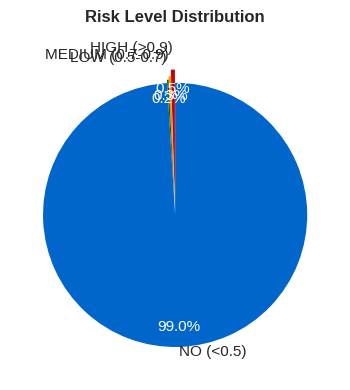

In [8]:
predictions = gpu_predictions

print("Prediction Statistics:\n")
print(f"Total predictions:        {len(predictions):,}")
print(f"Mean probability:         {predictions.mean():.4f}")
print(f"Median probability:       {np.median(predictions):.4f}")
print(f"Std deviation:            {predictions.std():.4f}")
print(f"Min probability:          {predictions.min():.6f}")
print(f"Max probability:          {predictions.max():.6f}")

# Risk classification - THIS WAS MISSING!
high_risk = (predictions > 0.9).sum()
medium_risk = ((predictions > 0.7) & (predictions <= 0.9)).sum()
low_risk = ((predictions > 0.5) & (predictions <= 0.7)).sum()
no_risk = (predictions <= 0.5).sum()

print(f"\nRisk Classification:")
print(f" HIGH risk (>0.9):      {high_risk:,} ({high_risk/len(predictions)*100:.2f}%)")
print(f" MEDIUM risk (0.7-0.9): {medium_risk:,} ({medium_risk/len(predictions)*100:.2f}%)")
print(f" LOW risk (0.5-0.7):    {low_risk:,} ({low_risk/len(predictions)*100:.2f}%)")
print(f" NO risk (<0.5):        {no_risk:,} ({no_risk/len(predictions)*100:.2f}%)")

# Visualization with better layout
fig, ax = plt.subplots(figsize=(7, 4))

risk_counts = [high_risk, medium_risk, low_risk, no_risk]
risk_labels = [
    f'HIGH (>0.9)\n', 
    f'MEDIUM (0.7-0.9)\n', 
    f'LOW (0.5-0.7)\n',
    f'NO (<0.5)\n'
]

# Red, Orange, Green, Blue
colors = ['#cc0000', '#ff8800', '#006600', '#0066cc']


# Create pie chart with labels outside
wedges, texts, autotexts = ax.pie(
    risk_counts, 
    labels=risk_labels, 
    colors=colors, 
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.85,  # Position percentages closer to center
    explode=(0.1, 0.05, 0.025, 0),  # Explode small slices for visibility
    textprops={'fontsize': 11}
)

# Make percentage text white for better contrast
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(11)

# Move labels outside
for text in texts:
    text.set_fontsize(11)

ax.set_title('Risk Level Distribution', fontsize=12, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

## 7.8 Prepare Model for Triton Inference Server

Package the model for deployment with NVIDIA Triton Inference Server.

In [9]:
print("Preparing model for Triton Inference Server...\n")

# Create Triton model repository structure
triton_repo = DEPLOYMENT_DIR / "triton_model_repository"
model_name = "fraud_detection_xgboost"
model_version = "1"

model_dir = triton_repo / model_name / model_version
model_dir.mkdir(parents=True, exist_ok=True)

# Copy model file
triton_model_path = model_dir / "model.json"
import shutil
shutil.copy(json_path, triton_model_path)

print(f"Model copied to: {triton_model_path}")

# Create config.pbtxt for Triton
config_content = f'''name: "{model_name}"
backend: "python"
max_batch_size: 1024

input [
  {{
    name: "input_features"
    data_type: TYPE_FP32
    dims: [{len(feature_cols)}]
  }}
]

output [
  {{
    name: "fraud_probability"
    data_type: TYPE_FP32
    dims: [1]
  }}
]

instance_group [
  {{
    count: 1
    kind: KIND_GPU
  }}
]

dynamic_batching {{
  preferred_batch_size: [128, 256, 512, 1024]
  max_queue_delay_microseconds: 1000
}}
'''

config_path = triton_repo / model_name / "config.pbtxt"
with open(config_path, 'w') as f:
    f.write(config_content)

print(f"Config created: {config_path}")

# Create Python model wrapper for Triton
python_model_content = '''import json
import numpy as np
import xgboost as xgb
import triton_python_backend_utils as pb_utils

class TritonPythonModel:
    def initialize(self, args):
        """Initialize the model."""
        self.model_dir = args['model_repository']
        model_path = f"{self.model_dir}/1/model.json"
        
        # Load XGBoost model
        self.model = xgb.Booster()
        self.model.load_model(model_path)

        # Load feature names 
        feature_path = f"{self.model_dir}/1/feature_names.txt"
        with open(feature_path, 'r') as f:
            self.feature_names = f.read().strip().split('\\n')
        
        print(f"Model loaded with {len(self.feature_names)} features")
        
    def execute(self, requests):
        """Execute inference on batch of requests."""
        responses = []
        
        for request in requests:
            # Get input tensor
            input_tensor = pb_utils.get_input_tensor_by_name(request, "input_features")
            input_data = input_tensor.as_numpy()
            
            # Create DMatrix WITH feature names 
            dmatrix = xgb.DMatrix(input_data, feature_names=self.feature_names)

            # Predict
            predictions = self.model.predict(dmatrix)
            
            # Create output tensor
            output_tensor = pb_utils.Tensor(
                "fraud_probability",
                predictions.astype(np.float32).reshape(-1, 1)
            )
            
            # Create response
            response = pb_utils.InferenceResponse(output_tensors=[output_tensor])
            responses.append(response)
        
        return responses
    
    def finalize(self):
        """Clean up resources."""
        pass
'''

python_model_path = model_dir / "model.py"
with open(python_model_path, 'w') as f:
    f.write(python_model_content)

print(f"Python model wrapper created: {python_model_path}")

# Save feature list for reference
feature_list_path = model_dir / "feature_names.txt"
with open(feature_list_path, 'w') as f:
    f.write('\n'.join(feature_cols))

print(f"Feature list saved: {feature_list_path}")


Preparing model for Triton Inference Server...

Model copied to: data/deployment/triton_model_repository/fraud_detection_xgboost/1/model.json
Config created: data/deployment/triton_model_repository/fraud_detection_xgboost/config.pbtxt
Python model wrapper created: data/deployment/triton_model_repository/fraud_detection_xgboost/1/model.py
Feature list saved: data/deployment/triton_model_repository/fraud_detection_xgboost/1/feature_names.txt


## 7.9 Deployment and Inference Guide

Guide to deploy the model, test trition server, and make inference on a single transaction
**Project Structure:**
```
gtc-26-ml-ops/
├── data/
│   └── deployment/
│       └── triton_model_repository/
│           └── fraud_detection_xgboost/
│               ├── config.pbtxt
│               └── 1/
│                   ├── model.json
│                   ├── model.py
│                   └── feature_names.txt
├── triton_inference.py
└── test_triton.py
```

### Terminal 1: Start Triton Server
**Note: for this workshop, the Triton server is already running in the backend, thus you don't need to execute the code in this section. But for your own practice off the workshop, you need to start Triton server and deploy the model before you can do inference.**
#### Step 1: Navigate to Project Directory
```bash
cd /dli/task
```

#### Step 2: Start Triton Inference Server
```bash
docker run --gpus all --rm \
  -p 8000:8000 -p 8001:8001 -p 8002:8002 \
  -v $(pwd)/data/deployment/triton_model_repository:/models \
  nvcr.io/nvidia/tritonserver:24.01-py3 \
  bash -c "pip install xgboost numpy && tritonserver --model-repository=/models"
```

**What this does:**
- `--gpus all`: Enable all available GPUs
- `-p 8000:8000`: HTTP endpoint for inference
- `-p 8001:8001`: gRPC endpoint for inference
- `-p 8002:8002`: Metrics endpoint
- `-v`: Mount your model repository
- `pip install xgboost numpy`: Install required dependencies
- `tritonserver --model-repository=/models`: Start the server
#### step 3: Verify Server is Ready
```
=============================
== Triton Inference Server ==
=============================

NVIDIA Release 24.01 (build 80100513)
Triton Server Version 2.42.0

...

Successfully installed xgboost-3.1.3 numpy-1.26.3

+-------------------------+---------+--------+
| Model                   | Version | Status |
+-------------------------+---------+--------+
| fraud_detection_xgboost | 1       | READY  |  ← Model is ready!
+-------------------------+---------+--------+

Started HTTPService at 0.0.0.0:8000
Started GRPCInferenceService at 0.0.0.0:8001
Started Metrics Service at 0.0.0.0:8002
```

### Terminal 2: Run Client Inference
**Open a NEW terminal window for client operations**
#### Step 1: Install Triton Client Libraries
```bash
# Install Triton client with all protocols (HTTP, gRPC)
python -m pip install tritonclient[all]
```

**Installed packages:**
- `tritonclient` - Main client library
- `grpcio` - gRPC protocol support
- `geventhttpclient` - HTTP protocol support
- `protobuf` - Message serialization
#### Step 2: Test Server Connection
```bash
# Navigate to project directory
cd /dli/task

# Run health check
python test_triton.py
```

**Expected Output:**
```
============================================================
TRITON SERVER STATUS
============================================================
Server Live: True
Server Ready: True
Model Ready: True
============================================================
```

If all three show `True`, you're ready to proceed! 
#### Step 3: Run Inference (Standard Mode)
```bash
python triton_inference.py
```
#### Step 4: Run Inference (GPU-Accelerated Mode)
```bash
python -m cudf.pandas triton_inference.py
```

## 7.10 Check Triton & Model Status

This section documents a few useful `curl -v` commands for interacting with a
Triton Inference Server instance running on localhost.

### Health: Server Readiness

Command:
    curl -v http://triton:8000/v2/health/ready

Description:
    Checks whether the Triton server is *ready* to serve inference requests. The endpoint implements the standard "server ready" health API from the V2 inference protocol and returns HTTP 200 when the server is up and able to respond to inference requests (subject to Triton’s strict-readiness configuration). Any non-200 status indicates the server is not ready.

### Server Metadata (Root of V2 API)

Command:
    curl -v http://triton:8000/v2

Description:
    Queries the Triton server metadata root for the HTTP/REST V2 API.
    Returns a JSON document with basic information about the server,
    including:
      - Server name (for example, "triton")
      - Server version
      - Supported protocol extensions (classification, model_repository, statistics, etc.)

    A successful HTTP 200 response here confirms that the V2 HTTP API is reachable and active.

### Model Metadata

Command:
    curl -v http://triton:8000/v2/models/fraud_detection_xgboost

Description:
    Retrieves metadata for the model named "fraud_detection_xgboost".
    This is the V2 *model metadata* API. On success, the server returns
    HTTP 200 and a JSON body that contains, at minimum:

      - "name": model name
      - "versions": list of available versions (optional)
      - "platform": backend/platform string
      - "inputs": list of input tensors (name, datatype, shape)
      - "outputs": list of output tensors (name, datatype, shape)

    This endpoint is useful to verify that a model is loaded and to inspect its input/output contract (for example, tensor shapes and data types) before sending inference requests. 

### Metrics (Prometheus)

Command:
    curl -v http://triton:8002/metrics

Description:
    Exposes Triton’s Prometheus-format metrics endpoint. By default,
    Triton serves metrics on port 8002 at the `/metrics` path.
    The response is plain text in Prometheus exposition format and
    typically includes:

      - Request counters (e.g., `nv_inference_request_success`, `nv_inference_request_failure`)
      - Inference counts and execution counts per model
      - Latency metrics (request, queue, compute input/infer/output)
      - GPU metrics (utilization, memory usage, power, energy)
      - CPU and memory metrics

    Monitoring systems such as Prometheus or Grafana scrape this endpoint to track Triton performance and resource usage over time. 
